# QDF → MMFF 가중치 → GraphCL 마이크로벤치 (CPU vs XPU)

**전체 과정(앙상블 준비 파이프라인)** 을 한 번에 돌리고, **실행마다 타임스탬프 폴더 1개**에 CPU·XPU 결과·로그·그래프를 모읍니다.

| 단계 | 도구 | 설명 |
|------|------|------|
| 1 | `qdf_mmff_predict.py` | ESOL 등 MoleculeNet × MMFF 슬롯마다 QDF 추론 → CSV |
| 2 | `compute_mmff_weights.py` | CSV → 슬롯 가중치 `.pt` (`WeightedMMFFView` 등에 사용) |
| 3 | `compare_pretrain_ab.py` | GraphCL **마이크로** pretrain (A/B) + CPU·XPU%·RSS 샘플링 |

**기존 노트북과의 관계**

- 품질·다운스트림까지 포함한 전체 비교: `compare_pretrain_quality.ipynb`
- 속도 A/B만: `run_pretrain_compare.ipynb` / `compare_pretrain_ab.py`

본 노트북은 위 스크립트들을 **오케스트레이션**만 하며, 상세 수치는 생성 폴더의 `manifest.json`, `cpu/steps.json`, `xpu/steps.json`, `*/pretrain_ab/pretrain_ab_results.json`, `SUMMARY.md` 를 기준으로 합니다.

## 실행 전 확인

- 레포 루트에서 열고, 커널은 **이 프로젝트 `.venv`** (README의 `3dgcl` 커널 권장).
- `dataset/` 아래 대상 데이터셋(기본 `esol`)이 PyG 형식으로 존재해야 합니다.
- QDF 체크포인트: `--qdf-property atomization`(기본)은 `QuantumDeepField_molecule/output/...` preset 경로를 사용합니다.
- **XPU**: `torch+xpu` 빌드에서 `torch.xpu.is_available()` 가 True일 때만 자동으로 XPU 구간을 돕니다. 그렇지 않으면 CPU만 돌고 `SUMMARY.md`에 스킵 사유를 적습니다. 강제 시도는 오케스트레이터 인자 `--no-skip-xpu` 를 사용하세요.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
for p in [REPO, *REPO.parents]:
    if (p / "dig").is_dir() and (p / "QuantumDeepField_molecule").is_dir():
        REPO = p
        break

BENCH = REPO / "examples" / "sslgraph" / "bench"
ORCH = BENCH / "ensemble_cpu_xpu_orchestrator.py"

# True: QDF 예측 분자 수 제한 + pretrain max-iters 축소 (빠른 검증)
SMOKE = True
QDF_LIMIT = 128 if SMOKE else 0
PRETRAIN_MAX_ITERS = 6 if SMOKE else 24
PRETRAIN_BATCH = 96 if SMOKE else 128

# XPU가 없는 환경에서도 스크립트가 돌아가게 하려면 True (XPU 구간 스킵)
ALLOW_SKIP_XPU = True

print("REPO =", REPO)
print("ORCH exists =", ORCH.is_file())

REPO = C:\DGCL\3DGCL
ORCH exists = True


In [2]:
if not ORCH.is_file():
    raise FileNotFoundError(ORCH)

cmd = [
    sys.executable,
    str(ORCH),
    "--dataset",
    "esol",
    "--root",
    "dataset/",
    "--qdf-property",
    "atomization",
    "--limit",
    str(QDF_LIMIT),
    "--pretrain-batch-size",
    str(PRETRAIN_BATCH),
    "--pretrain-max-iters",
    str(PRETRAIN_MAX_ITERS),
    "--pretrain-epochs",
    "1",
    "--pretrain-warmup",
    "1",
]
if not ALLOW_SKIP_XPU:
    cmd.append("--no-skip-xpu")

print("$", " ".join(cmd))
r = subprocess.run(cmd, cwd=str(REPO))
print("exit_code =", r.returncode)

$ c:\DGCL\3DGCL\.venv\Scripts\python.exe C:\DGCL\3DGCL\examples\sslgraph\bench\ensemble_cpu_xpu_orchestrator.py --dataset esol --root dataset/ --qdf-property atomization --limit 128 --pretrain-batch-size 96 --pretrain-max-iters 6 --pretrain-epochs 1 --pretrain-warmup 1
exit_code = 0


## 결과 폴더 (가장 최근 `qdf_ensemble_cpu_xpu_*`)

아래 셀이 `figs/` 에서 최신 실행 폴더를 골라 **단계별 표**와 **비교 PNG** 를 표시합니다.

RUN = C:\DGCL\3DGCL\examples\sslgraph\bench\figs\qdf_ensemble_cpu_xpu_20260514_140736


,mode,step,wall_sec,returncode,log
0,cpu,01_qdf_mmff_predict,26.727482,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...
1,cpu,02_compute_mmff_weights,5.083304,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...
2,cpu,03_compare_pretrain_ab,576.309471,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...
3,xpu,01_qdf_mmff_predict,22.774034,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...
4,xpu,02_compute_mmff_weights,5.723967,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...
5,xpu,03_compare_pretrain_ab,24.305664,0,examples/sslgraph/bench/figs/qdf_ensemble_cpu_...


### `cpu` — compare_pretrain_ab 요약

,wall_s,peak_rss_mb,mean_rss_mb,mean_cpu_pct,peak_cpu_pct,mean_xpu_pct,peak_xpu_pct,n_samples
A (baseline),8.386713,1381.582031,1317.084162,99.271881,100.0,0.0,0.0,55
B (fast+bf16),560.390463,1684.773438,1513.990237,99.975069,100.0,0.0,0.0,3735


### `xpu` — compare_pretrain_ab 요약

,wall_s,peak_rss_mb,mean_rss_mb,mean_cpu_pct,peak_cpu_pct,mean_xpu_pct,peak_xpu_pct,n_samples
A (baseline),10.677507,4156.617188,3359.088248,94.428622,100.0,58.419562,100.000000,71
B (fast+bf16),6.501044,4713.109375,4595.492278,96.444031,100.0,57.101500,107.030923,43


### `compare_wall_by_step.png`

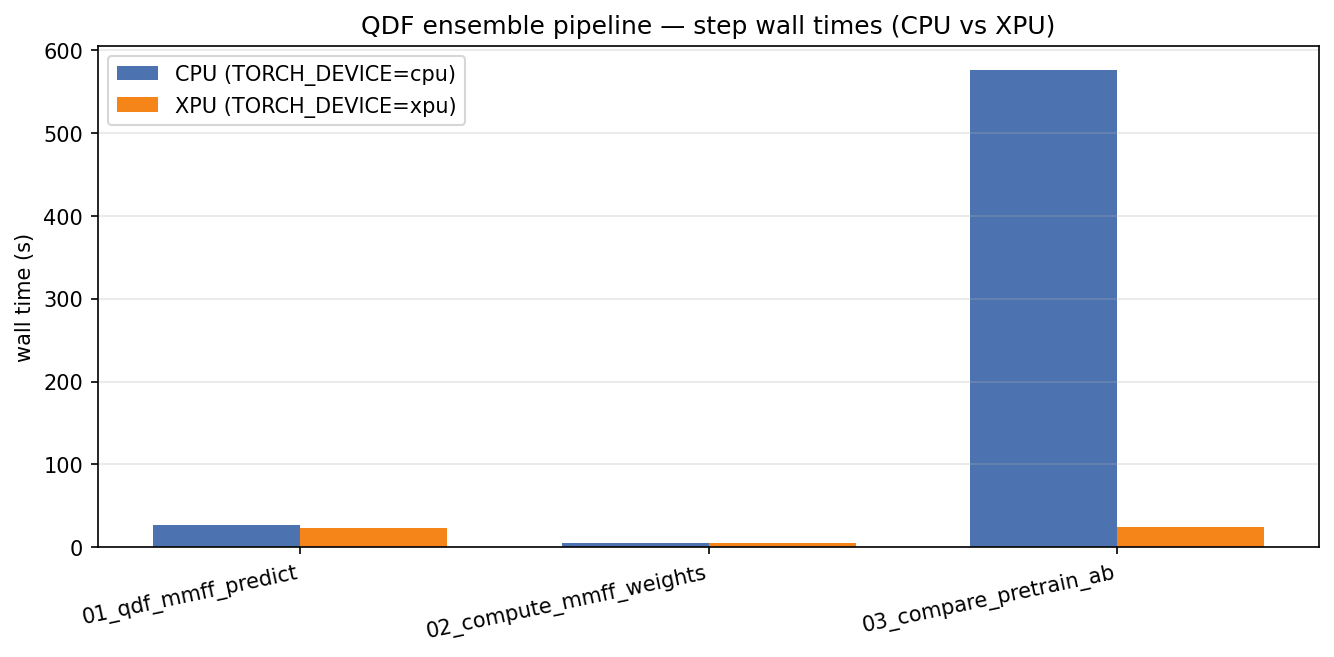

### `compare_resources.png`

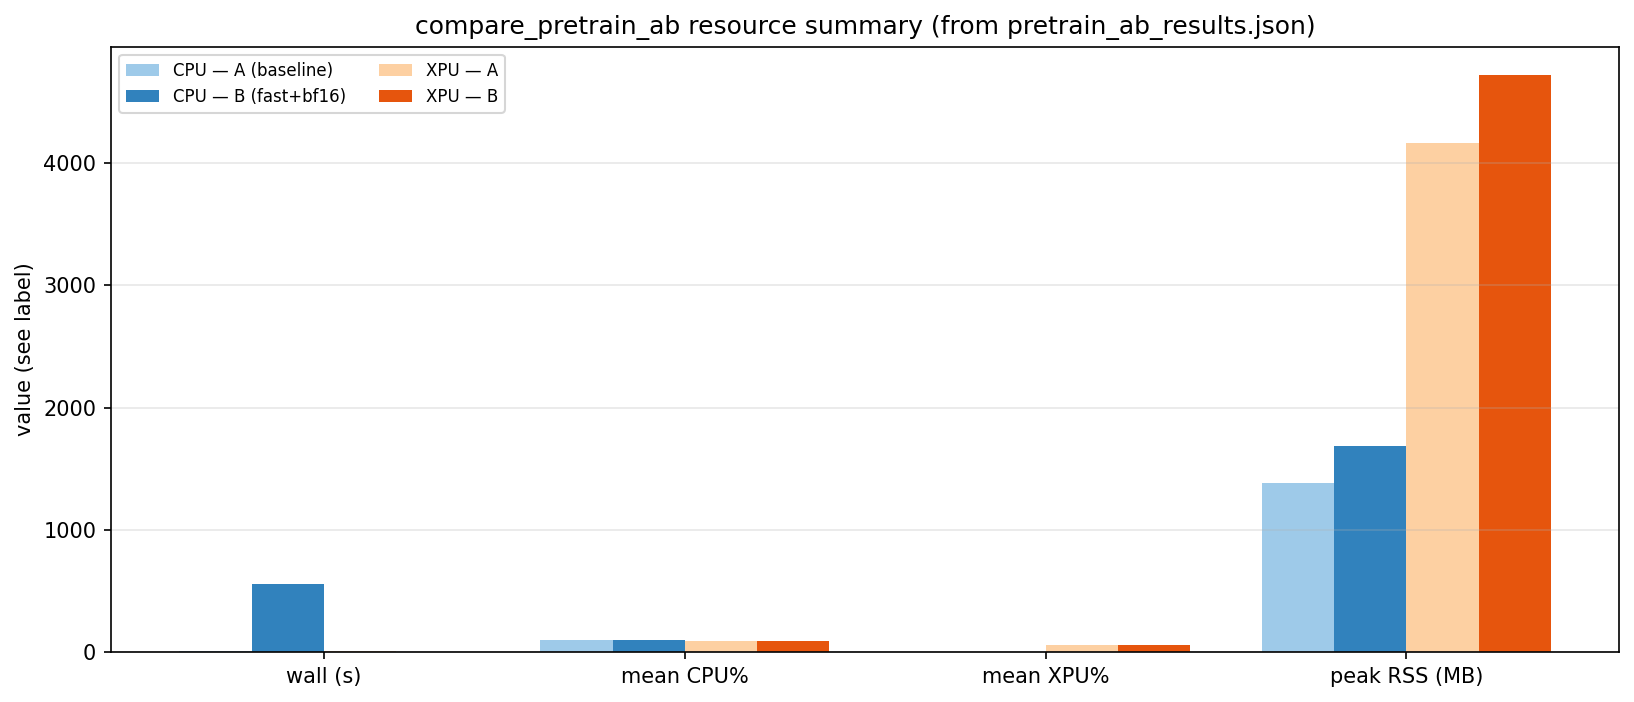

In [3]:
from IPython.display import Image, display, Markdown
import pandas as pd

figs = BENCH / "figs"
cands = sorted(figs.glob("qdf_ensemble_cpu_xpu_*"), key=lambda p: p.stat().st_mtime, reverse=True)
if not cands:
    raise FileNotFoundError("아직 figs/qdf_ensemble_cpu_xpu_* 가 없습니다. 위 셀을 먼저 실행하세요.")

RUN = cands[0]
print("RUN =", RUN)

manifest = json.loads((RUN / "manifest.json").read_text(encoding="utf-8"))
rows = []
for mode in ("cpu", "xpu"):
    p = RUN / mode / "steps.json"
    if not p.is_file():
        continue
    for s in json.loads(p.read_text(encoding="utf-8")):
        rows.append({"mode": mode, **s})
df_steps = pd.DataFrame(rows)
display(df_steps)

# pretrain_ab JSON (A/B wall, CPU%, XPU%, RSS)
def show_pretrain_summary(mode: str):
    jp = RUN / mode / "pretrain_ab" / "pretrain_ab_results.json"
    if not jp.is_file():
        display(Markdown(f"*{mode}: pretrain_ab_results.json 없음*"))
        return
    d = json.loads(jp.read_text(encoding="utf-8"))
    sa, sb = d.get("summary_a") or {}, d.get("summary_b") or {}
    sub = pd.DataFrame([sa, sb], index=["A (baseline)", "B (fast+bf16)"])
    display(Markdown(f"### `{mode}` — compare_pretrain_ab 요약"))
    display(sub)


show_pretrain_summary("cpu")
show_pretrain_summary("xpu")

for name in ("compare_wall_by_step.png", "compare_resources.png"):
    png = RUN / name
    if png.is_file():
        display(Markdown(f"### `{name}`"))
        display(Image(filename=str(png)))